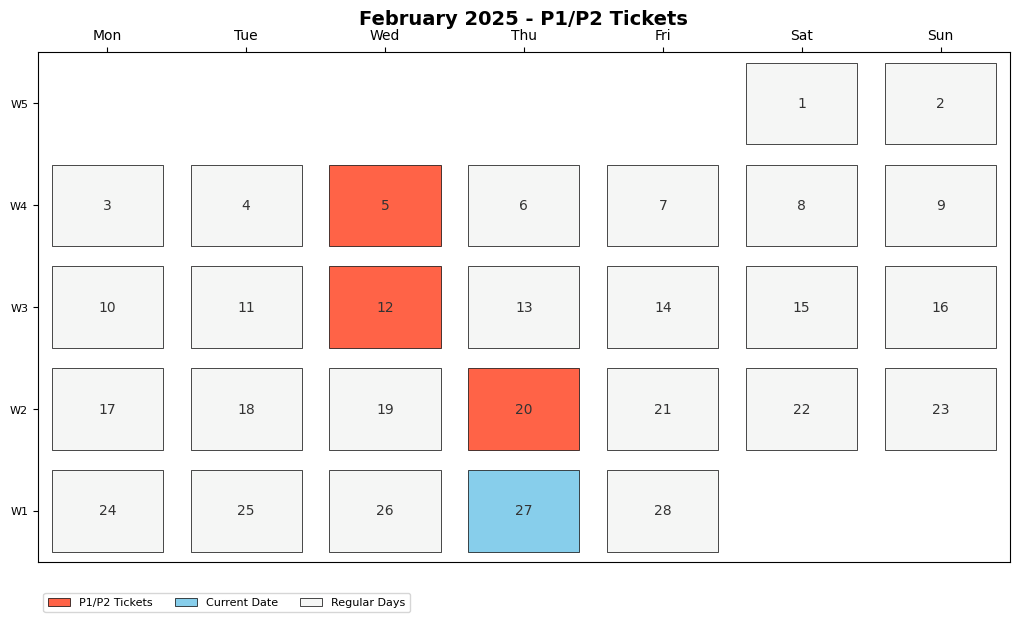

In [2]:
import calendar
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# Set the year and month
year = 2025
month = 2  # February
current_date = datetime(2025, 2, 27).date()  # Reference date from your context

# Sample data: Days in February 2025 when P1/P2 tickets occurred
p1p2_days = [5, 12, 20]  # Replace with your actual ticket data

# Create a calendar object
cal = calendar.monthcalendar(year, month)
month_name = calendar.month_name[month]

# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title(f"{month_name} {year} - P1/P2 Tickets", pad=20, fontsize=14, fontweight='bold')

# Define colors
normal_day_color = '#F5F6F5'    # Light gray
highlight_color = '#FF6347'     # Tomato red
current_day_color = '#87CEEB'   # Light blue for current date
text_color = '#333333'          # Dark gray

# Create the calendar grid
rows = len(cal)
cols = 7
for i in range(rows):
    for j in range(cols):
        day = cal[i][j]
        if day != 0:  # Valid days in the month
            # Determine cell color
            cell_date = datetime(year, month, day).date()
            if day in p1p2_days and cell_date == current_date:
                color = current_day_color  # Special case for current date with ticket
            elif day in p1p2_days:
                color = highlight_color
            elif cell_date == current_date:
                color = current_day_color
            else:
                color = normal_day_color

            # Draw rectangle
            rect = plt.Rectangle((j-0.4, rows-1-i-0.4), 0.8, 0.8,
                               facecolor=color, edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)

            # Add day number
            ax.text(j, rows-1-i, day, ha='center', va='center',
                   fontsize=10, color=text_color)

# Customize the plot
ax.set_xticks(np.arange(cols))
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], fontsize=10)
ax.set_yticks(np.arange(rows))
ax.set_yticklabels([f'W{i+1}' for i in range(rows)], fontsize=8)  # Week numbers
ax.set_xlim(-0.5, cols-0.5)
ax.set_ylim(-0.5, rows-0.5)
ax.grid(False)

# Move x-axis labels to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Add legend
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=highlight_color, edgecolor='black',
                 linewidth=0.5, label='P1/P2 Tickets'),
    plt.Rectangle((0, 0), 1, 1, facecolor=current_day_color, edgecolor='black',
                 linewidth=0.5, label='Current Date'),
    plt.Rectangle((0, 0), 1, 1, facecolor=normal_day_color, edgecolor='black',
                 linewidth=0.5, label='Regular Days')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, -0.05),
         ncol=3, fontsize=8)

# Adjust layout
plt.tight_layout(pad=0)
plt.savefig("calendar_p1p2_tickets_feb2025.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.show()

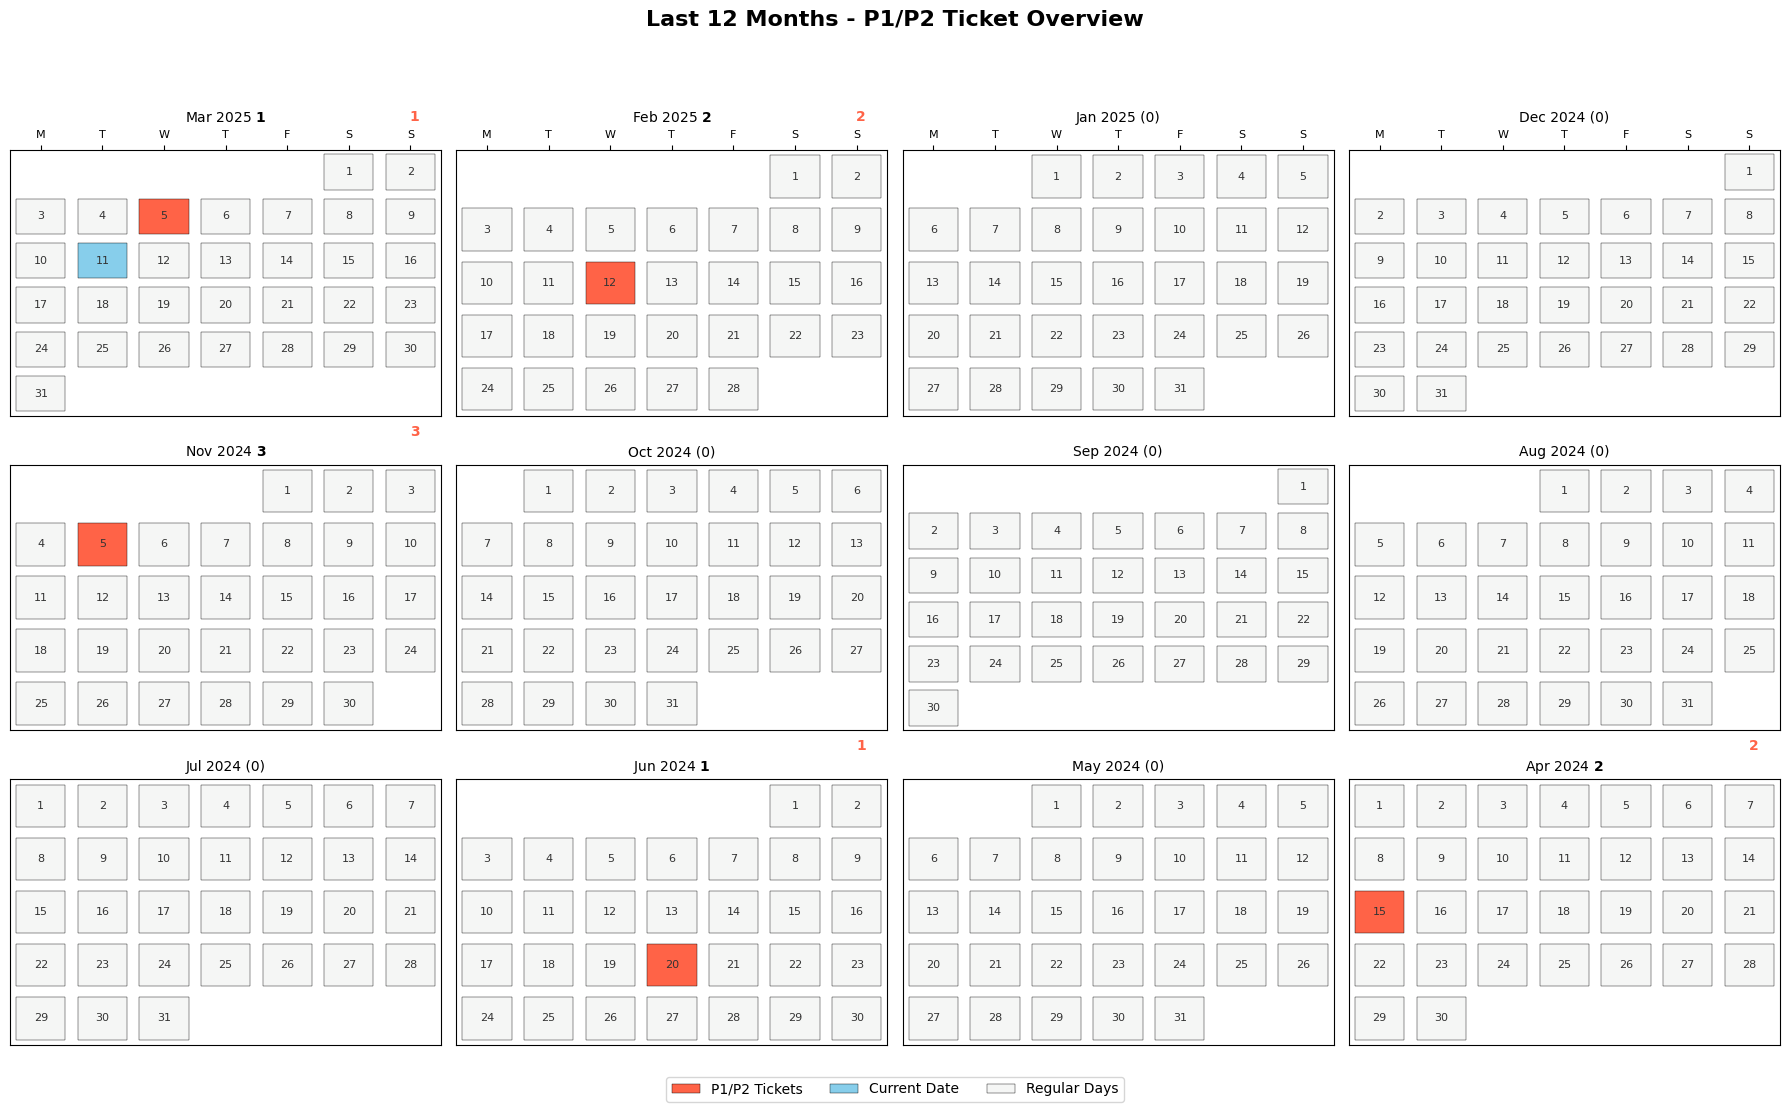

In [8]:
import calendar
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta

# Current date (March 11, 2025)
current_date = datetime(2025, 3, 11).date()

# Sample P1/P2 ticket data (replace with your actual data)
ticket_data = {
    datetime(2024, 4, 15).date(): 2,
    datetime(2024, 6, 20).date(): 1,
    datetime(2024, 11, 5).date(): 3,
    datetime(2025, 2, 12).date(): 2,
    datetime(2025, 3, 5).date(): 1
}

# Calculate monthly ticket counts
monthly_counts = {}
for date, count in ticket_data.items():
    key = (date.year, date.month)
    monthly_counts[key] = monthly_counts.get(key, 0) + count

# Create figure with 3x4 subplots
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
fig.suptitle('Last 12 Months - P1/P2 Ticket Overview', fontsize=16, fontweight='bold', y=1.05)

# Colors
normal_day_color = '#F5F6F5'    # Light gray
highlight_color = '#FF6347'     # Tomato red (used for tickets and count highlight)
current_day_color = '#87CEEB'   # Light blue
text_color = '#333333'          # Dark gray

# Generate 12 months backward from current date
for i in range(12):
    month_date = current_date - relativedelta(months=i)
    year = month_date.year
    month = month_date.month

    # Get subplot position (3 rows, 4 columns)
    row = i // 4
    col = i % 4
    ax = axes[row, col]

    # Create calendar
    cal = calendar.monthcalendar(year, month)
    month_name = calendar.month_name[month][:3]  # Short month name

    # Get ticket count for this month
    ticket_count = monthly_counts.get((year, month), 0)

    # Set title with highlighted count (red and bold when > 0)
    if ticket_count > 0:
        title_text = f"{month_name} {year} " + r"$\bf{" + f"{ticket_count}" + "}$"
        ax.set_title(title_text, fontsize=10, color='black')
        # Add colored text for count separately
        ax.text(0.95, 1.15, str(ticket_count), transform=ax.transAxes,
                fontsize=10, color=highlight_color, fontweight='bold',
                ha='right', va='top')
    else:
        ax.set_title(f"{month_name} {year} ({ticket_count})", fontsize=10)

    # Create grid
    rows = len(cal)
    cols = 7

    for week_idx, week in enumerate(cal):
        for day_idx, day in enumerate(week):
            if day != 0:
                cell_date = datetime(year, month, day).date()
                # Determine color
                if cell_date == current_date and cell_date in ticket_data:
                    color = current_day_color
                elif cell_date in ticket_data:
                    color = highlight_color
                elif cell_date == current_date:
                    color = current_day_color
                else:
                    color = normal_day_color

                # Draw rectangle
                rect = plt.Rectangle((day_idx-0.4, rows-1-week_idx-0.4), 0.8, 0.8,
                                   facecolor=color, edgecolor='black', linewidth=0.3)
                ax.add_patch(rect)

                # Add day number
                ax.text(day_idx, rows-1-week_idx, day, ha='center', va='center',
                       fontsize=8, color=text_color)

    # Customize subplot
    if row == 0:  # Only show weekday labels on top row
        ax.set_xticks(np.arange(cols))
        ax.set_xticklabels(['M', 'T', 'W', 'T', 'F', 'S', 'S'], fontsize=8)
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
    else:
        ax.set_xticks([])

    ax.set_yticks([])
    ax.set_xlim(-0.5, cols-0.5)
    ax.set_ylim(-0.5, rows-0.5)

# Add legend
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=highlight_color, edgecolor='black',
                 linewidth=0.3, label='P1/P2 Tickets'),
    plt.Rectangle((0, 0), 1, 1, facecolor=current_day_color, edgecolor='black',
                 linewidth=0.3, label='Current Date'),
    plt.Rectangle((0, 0), 1, 1, facecolor=normal_day_color, edgecolor='black',
                 linewidth=0.3, label='Regular Days')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.01),
          ncol=3, fontsize=10)

# Adjust layout
plt.tight_layout()
plt.savefig("year_view_p1p2_tickets_3x4_highlighted_counts.png", dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()

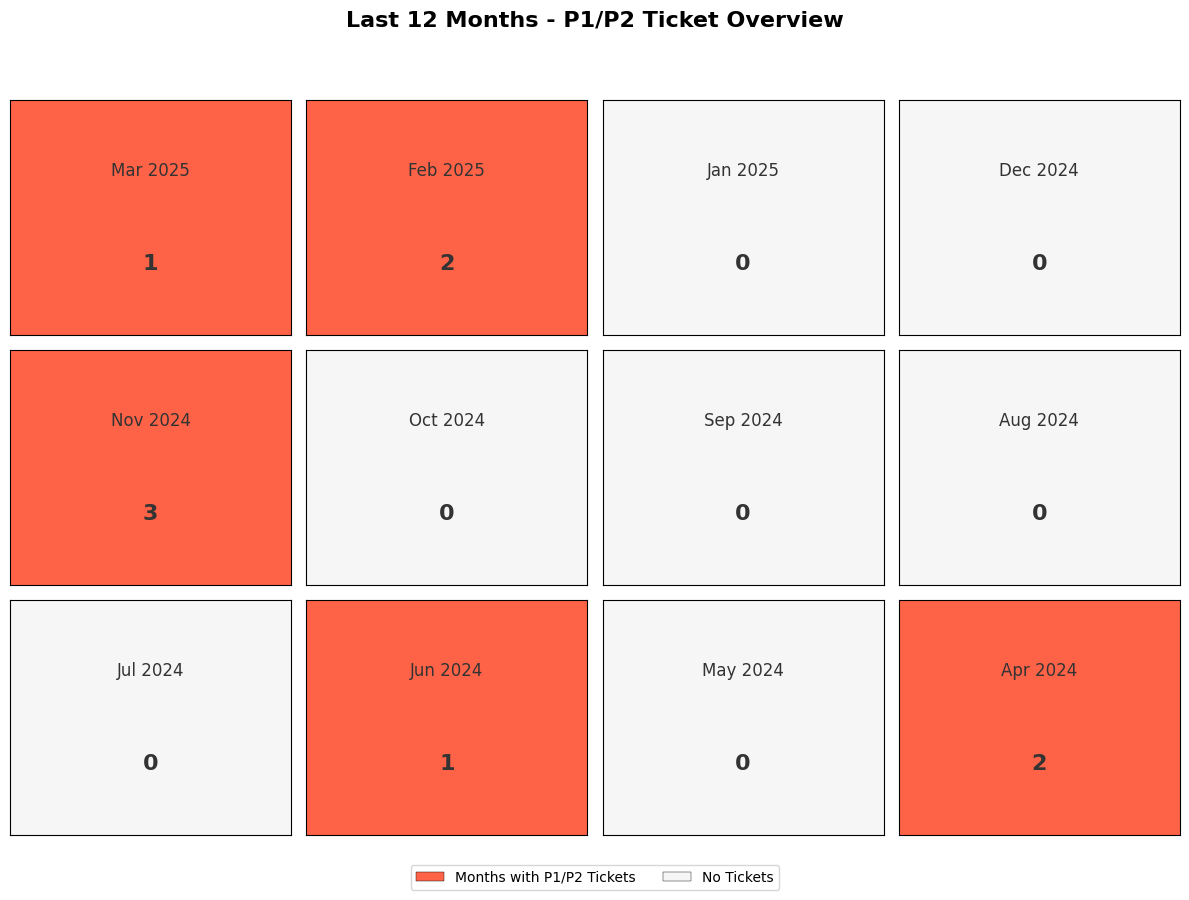

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta

# Current date (March 11, 2025)
current_date = datetime(2025, 3, 11).date()

# Sample P1/P2 ticket data (replace with your actual data)
ticket_data = {
    datetime(2024, 4, 15).date(): 2,
    datetime(2024, 6, 20).date(): 1,
    datetime(2024, 11, 5).date(): 3,
    datetime(2025, 2, 12).date(): 2,
    datetime(2025, 3, 5).date(): 1
}

# Calculate monthly ticket counts
monthly_counts = {}
for date, count in ticket_data.items():
    key = (date.year, date.month)
    monthly_counts[key] = monthly_counts.get(key, 0) + count

# Create figure with 3x4 subplots
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
fig.suptitle('Last 12 Months - P1/P2 Ticket Overview', fontsize=16, fontweight='bold', y=1.05)

# Colors
normal_color = '#F5F6F5'        # Light gray for no tickets
highlight_color = '#FF6347'     # Tomato red for tickets
text_color = '#333333'          # Dark gray for text

# Generate 12 months backward from current date
for i in range(12):
    month_date = current_date - relativedelta(months=i)
    year = month_date.year
    month = month_date.month

    # Get subplot position (3 rows, 4 columns)
    row = i // 4
    col = i % 4
    ax = axes[row, col]

    # Get month name and ticket count
    month_name = datetime(year, month, 1).strftime('%b')  # Short month name
    ticket_count = monthly_counts.get((year, month), 0)

    # Set background color based on ticket count
    bg_color = highlight_color if ticket_count > 0 else normal_color
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                              facecolor=bg_color, edgecolor='black', linewidth=0.5))

    # Display month and year
    ax.text(0.5, 0.7, f"{month_name} {year}",
            ha='center', va='center', fontsize=12, color=text_color)

    # Display ticket count
    ax.text(0.5, 0.3, f"{ticket_count}",
            ha='center', va='center', fontsize=16, fontweight='bold', color=text_color)

    # Remove axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Add legend
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=highlight_color, edgecolor='black',
                 linewidth=0.3, label='Months with P1/P2 Tickets'),
    plt.Rectangle((0, 0), 1, 1, facecolor=normal_color, edgecolor='black',
                 linewidth=0.3, label='No Tickets')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.01),
          ncol=2, fontsize=10)

# Adjust layout
plt.tight_layout()
plt.savefig("year_view_p1p2_highlighted_background_3x4.png", dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()